# import

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn
import scipy.stats

# code

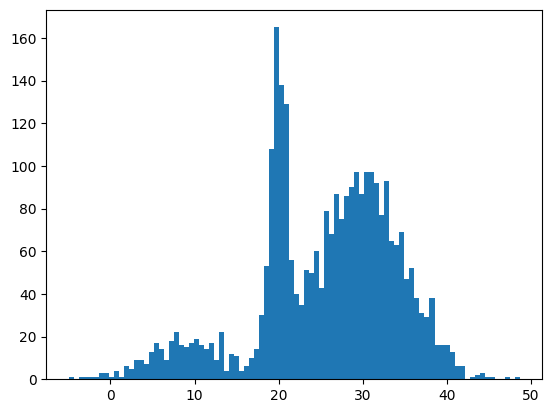

In [53]:
data = np.load('/home/matti/uni/astrostatistics_bicocca_2026/solutions/formationchannels.npy' )
# print (data)
plt.hist(data, 90);

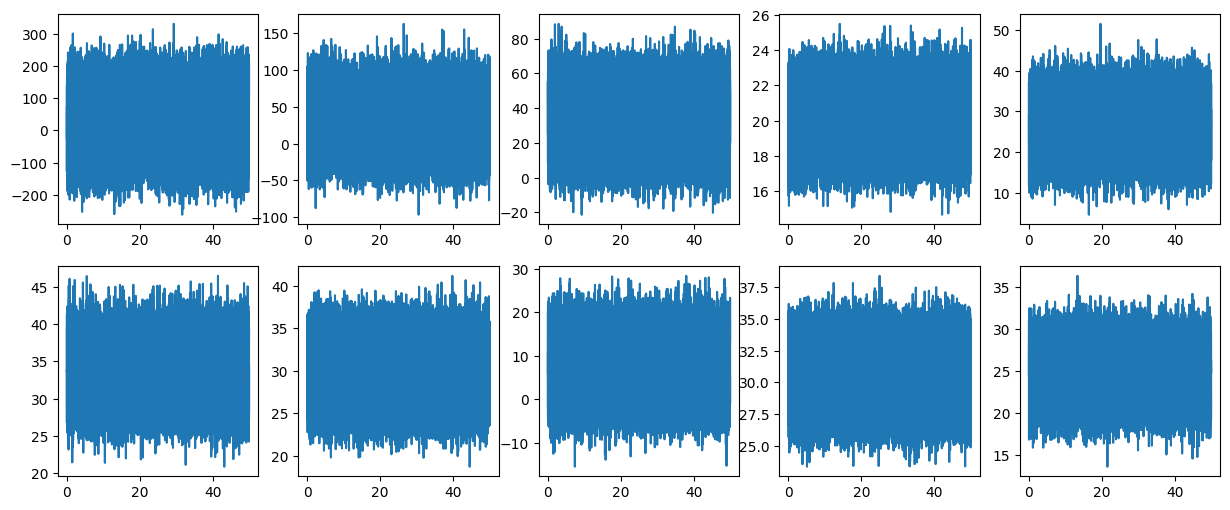

In [54]:
aic= np.zeros(10)
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
ax = ax.ravel()
x = np.linspace(0, 50, 100000)
for i, ax in enumerate (ax):
    data_fit = sklearn.mixture.GaussianMixture(n_components=i+1).fit(data)
    aic[i] = data_fit.aic(data)
    m =  data_fit.means_
    s = data_fit.covariances_
    w = data_fit.weights_
    y = np.random.normal(loc = m[0][0], scale = s[0][0], size = 100000)
    ax.plot(x, y)
    # print(s)

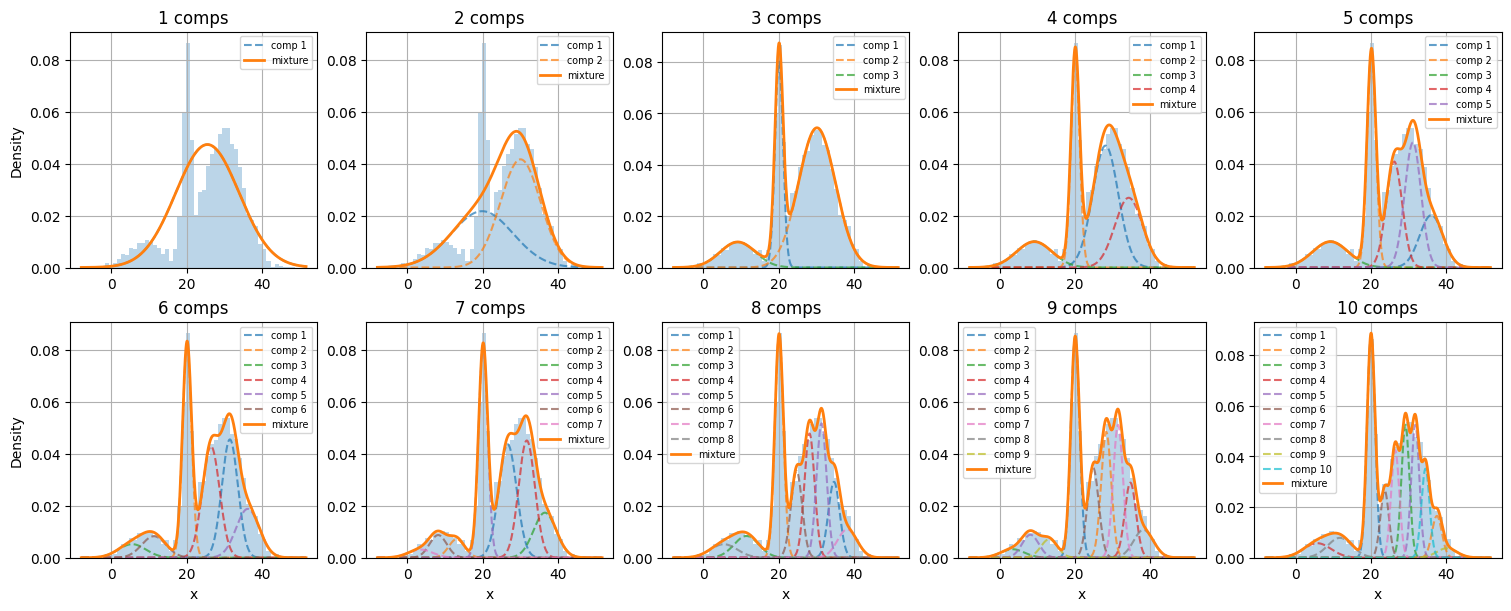

In [60]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), constrained_layout=True)
axes = axes.ravel()
x = np.linspace(data.min() - 3, data.max() + 3, 1000)

for i, ax in enumerate(axes):
    n_comp = i + 1
    data_fit = sklearn.mixture.GaussianMixture(n_components=n_comp)
    data_fit.fit(data)

    pdf = np.zeros_like(x)
    means = data_fit.means_.flatten()
    weights = data_fit.weights_.flatten()
    covs = data_fit.covariances_

    for k in range(n_comp):
        
        if covs.ndim == 3:
            var = float(covs[k].reshape(-1)[0])
        elif covs.ndim == 2:
            var = float(covs.reshape(-1)[0])
        else:
            var = float(covs[k])
        std = np.sqrt(var)
        pdf += weights[k] * scipy.stats.norm(loc=means[k], scale=std).pdf(x)
        ax.plot(x, weights[k] * scipy.stats.norm(loc=means[k], scale=std).pdf(x),
                linestyle='--', alpha=0.7, label=f'comp {k+1}')

    ax.hist(data.ravel(), bins=50, density=True, alpha=0.3, color='C0')
    ax.plot(x, pdf, color='C1', lw=2, label='mixture')
    ax.set_title(f'{n_comp} comps')
    ax.grid(True)
    if i % 5 == 0:
        ax.set_ylabel('Density')
    if i >= 5:
        ax.set_xlabel('x')
    ax.legend(fontsize='x-small')

plt.show()

Text(0, 0.5, 'Aic values')

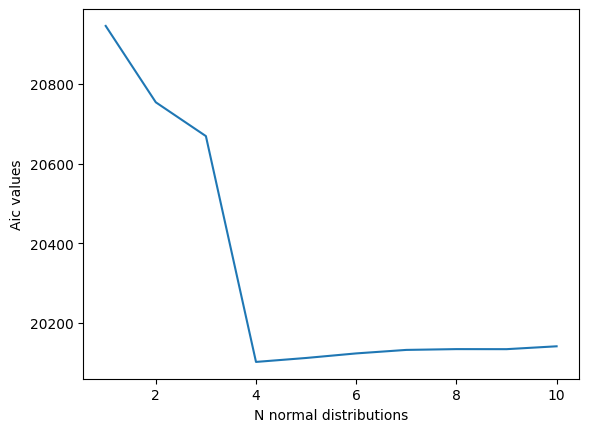

In [62]:
plt.plot(np.linspace(1, 10, 10), aic)
# plt.yscale('log')
plt.xlabel('N normal distributions')
plt.ylabel('Aic values')
